# 1. Carregamento dos dados



In [794]:
# Importação das principais bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.svm import SVC

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [731]:
# Leitura dos dados
df_ibov = pd.read_csv('Dados Históricos - Ibovespa.csv', sep=',')
df_ibov.head(3)

,Data,Último,Abertura,Máxima,Mínima,Vol.,Var%
0,27.01.2026,182.709,178.852,183.041,178.852,"3,76M","2,23%"
1,26.01.2026,178.721,178.859,179.543,177.694,"9,57B","-0,08%"
2,23.01.2026,178.859,175.590,180.532,175.590,"11,78B","1,86%"


# 2. Análise exploratória dos dados

In [732]:
# Alterando o título das colunas
df_ibov.rename(columns={'Data': 'data', 'Último': 'ultimo', 'Abertura': 'abertura', 'Máxima': 'maxima', 'Mínima': 'minima', 'Vol.': 'volume', 'Var%': 'variacao'}, inplace=True)
# 5 primeiras linhas.
df_ibov.head(3)

,data,ultimo,abertura,maxima,minima,volume,variacao
0,27.01.2026,182.709,178.852,183.041,178.852,"3,76M","2,23%"
1,26.01.2026,178.721,178.859,179.543,177.694,"9,57B","-0,08%"
2,23.01.2026,178.859,175.590,180.532,175.590,"11,78B","1,86%"


In [733]:
# Quantidade de linhas e colunas
df_ibov.shape

(519, 7)

In [734]:
# Cabeçalo e tipos de colunas
df_ibov.columns

Index(['data', 'ultimo', 'abertura', 'maxima', 'minima', 'volume', 'variacao'], dtype='object')

In [735]:
# Quais os tipos informações compõe o banco de dados (base original)
df_ibov.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 519 entries, 0 to 518
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   data      519 non-null    object 
 1   ultimo    519 non-null    float64
 2   abertura  519 non-null    float64
 3   maxima    519 non-null    float64
 4   minima    519 non-null    float64
 5   volume    519 non-null    object 
 6   variacao  519 non-null    object 
dtypes: float64(4), object(3)
memory usage: 28.5+ KB


In [736]:
# Transformando a coluna Data de objeto para data
df_ibov["data"] = pd.to_datetime(df_ibov["data"], format='%d.%m.%Y')
# Ordenar cronologicamente
df_ibov = df_ibov.sort_values("data")
df_ibov.head(3)

,data,ultimo,abertura,maxima,minima,volume,variacao
518,2024-01-02,132.697,134.186,134.195,132.095,"8,44M","-1,11%"
517,2024-01-03,132.834,132.697,133.576,132.250,"8,70M","0,10%"
516,2024-01-04,131.226,132.831,132.885,131.024,"8,97M","-1,21%"


In [737]:
# transformando em colunas float em inteiros (último, abertura maxima, minima)
colunas = ['ultimo', 'abertura', 'maxima', 'minima']
df_ibov[colunas] = (df_ibov[colunas]*1000).astype(int)
df_ibov.head(3)

,data,ultimo,abertura,maxima,minima,volume,variacao
518,2024-01-02,132697,134186,134195,132095,"8,44M","-1,11%"
517,2024-01-03,132834,132697,133576,132250,"8,70M","0,10%"
516,2024-01-04,131226,132831,132885,131024,"8,97M","-1,21%"


In [738]:
# transformando a coluna variação de object para float
df_ibov['variacao'] = df_ibov['variacao'].str.replace('%', '').str.replace(',', '.').astype(float)
df_ibov.head(3)

,data,ultimo,abertura,maxima,minima,volume,variacao
518,2024-01-02,132697,134186,134195,132095,"8,44M",-1.11
517,2024-01-03,132834,132697,133576,132250,"8,70M",0.10
516,2024-01-04,131226,132831,132885,131024,"8,97M",-1.21


In [739]:
# Criar Target (Tendência do Dia Seguinte)
df_ibov["target"] = np.where(df_ibov["ultimo"].shift(-1) > df_ibov["ultimo"], 0, 1)
df_ibov["var_targ"] = np.where(df_ibov["target"] == 0, "Baixa", "Alta")
df_ibov.head(3)

,data,ultimo,abertura,maxima,minima,volume,variacao,target,var_targ
518,2024-01-02,132697,134186,134195,132095,"8,44M",-1.11,0,Baixa
517,2024-01-03,132834,132697,133576,132250,"8,70M",0.10,1,Alta
516,2024-01-04,131226,132831,132885,131024,"8,97M",-1.21,0,Baixa


In [740]:
# Verificar a quantidade de dias em que houve alta e baixa
print(df_ibov['var_targ'].value_counts())
print(df_ibov['target'].value_counts())

var_targ
Baixa    273
Alta     246
Name: count, dtype: int64
target
0    273
1    246
Name: count, dtype: int64


In [741]:
# correlação entre variáveis (abertura, maxima, minima, volume)
# Convertendo a coluna 'volume' para float antes de calcular a correlação
def convert_volume(volume_str):
    volume_str = str(volume_str).replace('.', '').replace(',', '.')
    if 'M' in volume_str:
        return float(volume_str.replace('M', '')) * 1_000_000
    elif 'B' in volume_str:
        return float(volume_str.replace('B', '')) * 1_000_000_000
    else:
        return float(volume_str)

df_ibov['vol_reais'] = df_ibov['volume'].apply(convert_volume)
df_ibov.head(3)

,data,ultimo,abertura,maxima,minima,volume,variacao,target,var_targ,vol_reais
518,2024-01-02,132697,134186,134195,132095,"8,44M",-1.11,0,Baixa,8440000.0
517,2024-01-03,132834,132697,133576,132250,"8,70M",0.10,1,Alta,8700000.0
516,2024-01-04,131226,132831,132885,131024,"8,97M",-1.21,0,Baixa,8970000.0


In [742]:
# Transformando a coluna vol_reais em númeiro inteiro
df_ibov['vol_reais'] = df_ibov['vol_reais'].astype(int)
df_ibov.head()

,data,ultimo,abertura,maxima,minima,volume,variacao,target,var_targ,vol_reais
518,2024-01-02,132697,134186,134195,132095,"8,44M",-1.11,0,Baixa,8440000
517,2024-01-03,132834,132697,133576,132250,"8,70M",0.10,1,Alta,8700000
516,2024-01-04,131226,132831,132885,131024,"8,97M",-1.21,0,Baixa,8970000
515,2024-01-05,132023,131218,132635,130579,"9,20M",0.61,0,Baixa,9200000
514,2024-01-08,132427,132023,132498,131014,"8,50M",0.31,1,Alta,8500000


In [743]:
# Informações da base após ajustes
df_ibov.info()

<class 'pandas.core.frame.DataFrame'>
Index: 519 entries, 518 to 0
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   data       519 non-null    datetime64[ns]
 1   ultimo     519 non-null    int64         
 2   abertura   519 non-null    int64         
 3   maxima     519 non-null    int64         
 4   minima     519 non-null    int64         
 5   volume     519 non-null    object        
 6   variacao   519 non-null    float64       
 7   target     519 non-null    int64         
 8   var_targ   519 non-null    object        
 9   vol_reais  519 non-null    int64         
dtypes: datetime64[ns](1), float64(1), int64(6), object(2)
memory usage: 44.6+ KB


In [744]:
# validando dados nulos por gráfico - Não tem nulos
# df_ibov.isnull().sum()

In [745]:
# quais são os dados duplicados
df_ibov[df_ibov.duplicated()]

,data,ultimo,abertura,maxima,minima,volume,variacao,target,var_targ,vol_reais


## 2.1 Análise descritiva

In [746]:
df_ibov.describe().round(2)

,data,ultimo,abertura,maxima,minima,variacao,target,vol_reais
count,519,519.00,519.00,519.00,519.00,519.00,519.00,5.190000e+02
mean,2025-01-12 09:23:14.219653120,134332.30,134239.31,135119.17,133495.05,0.06,0.47,4.672798e+09
min,2024-01-02 00:00:00,118533.00,118534.00,119451.00,118223.00,-4.31,0.00,3.760000e+06
25%,2024-07-08 12:00:00,127125.00,127129.50,127838.50,126245.50,-0.44,0.00,9.340000e+06
50%,2025-01-14 00:00:00,130841.00,130841.00,131628.00,130121.00,0.05,0.00,4.950000e+09
75%,2025-07-22 12:00:00,137812.00,137786.50,138758.00,136710.50,0.57,1.00,8.865000e+09
max,2026-01-27 00:00:00,182709.00,178859.00,183041.00,178852.00,3.33,1.00,2.487000e+10
std,NaN,11374.28,11174.93,11374.94,11183.28,0.91,0.50,4.913548e+09


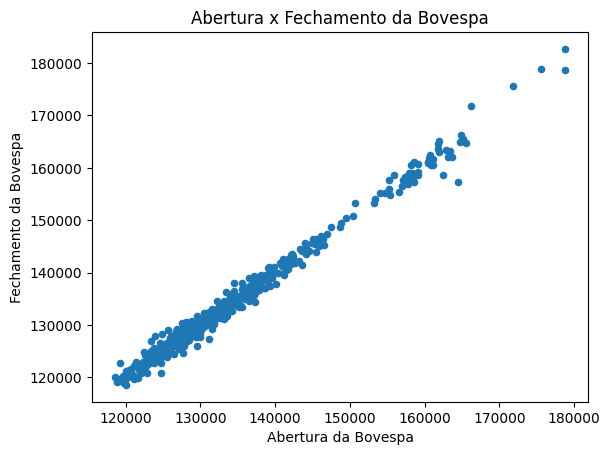

In [747]:
# Gráfico de disperssão
df_ibov.plot(x="abertura", y="ultimo", kind="scatter")

plt.xlabel("Abertura da Bovespa")
plt.ylabel("Fechamento da Bovespa")
plt.title("Abertura x Fechamento da Bovespa")
plt.show()

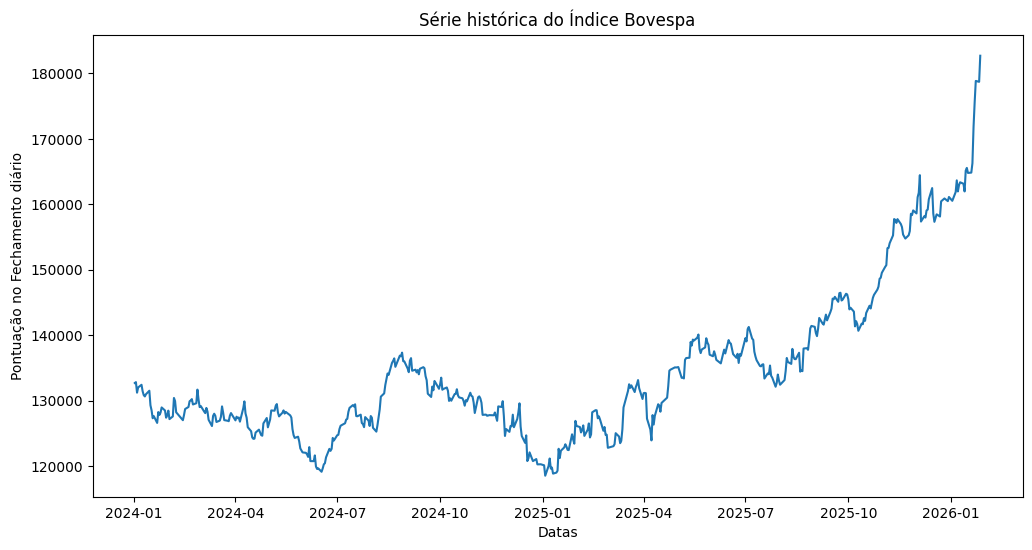

In [748]:
# Análise temporal (série histórica)
plt.figure(figsize=(12, 6))
plt.plot(df_ibov["data"], df_ibov["ultimo"])
plt.xlabel("Datas")
plt.ylabel("Pontuação no Fechamento diário")
plt.title("Série histórica do Índice Bovespa")
plt.show()

<Axes: xlabel='ultimo', ylabel='Count'>

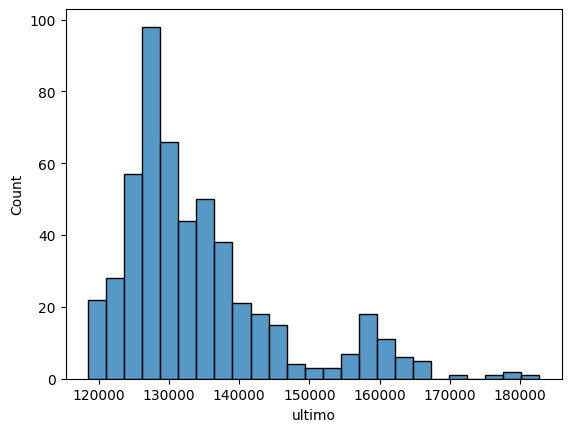

In [749]:
# Histograma em que podemos ver que da série histórica a maior parte do período o Ibovespa
# ficou em 125k e 140 k pontos
sns.histplot(data=df_ibov, x="ultimo")

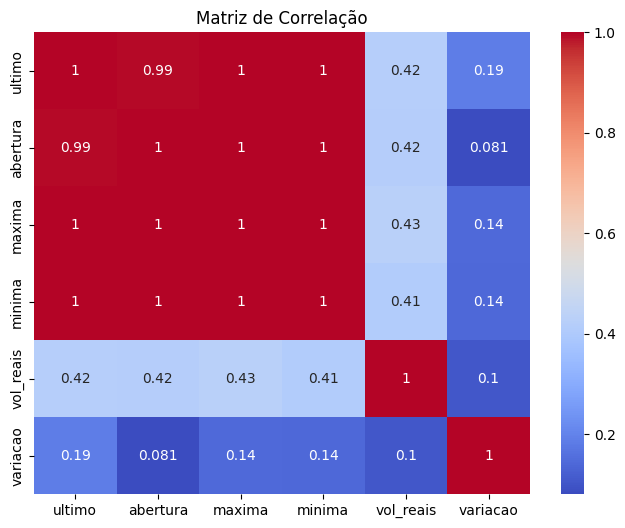

In [750]:
# correlação entre variáveis (abertura, maxima, minima, volume)
cols_numericas_for_corr = ['ultimo', 'abertura', 'maxima', 'minima', 'vol_reais', 'variacao']

plt.figure(figsize=(8,6))
sns.heatmap(df_ibov[cols_numericas_for_corr].corr(), annot=True, cmap="coolwarm")
plt.title("Matriz de Correlação")
plt.show()

## 2.2 Feature Engineering

### 2.2.1 Retorno diário

In [751]:
df_ibov["retorno_diario"] = df_ibov["ultimo"].pct_change()
# Distribuição de Retornos

### 2.2.2 Médias móveis

In [752]:
df_ibov["MM_05"] = df_ibov["ultimo"].rolling(5).mean()
df_ibov["MM_10"] = df_ibov["ultimo"].rolling(10).mean()


### 2.2.3 Volatilidade

In [753]:
df_ibov["volatility_diaria"] = df_ibov["retorno_diario"].std()
df_ibov["volatility_5"] = df_ibov["retorno_diario"].rolling(5).std()
df_ibov["volatility_10"] = df_ibov["retorno_diario"].rolling(10).std()


### 2.2.4. Momentum

In [754]:
# Mercado Financeiro (Investimento): Estratégia que aposta que ações com bom desempenho recente continuarão subindo, e as de mau desempenho continuarão caindo.
df_ibov["momentum_5"] = df_ibov["ultimo"].shift(periods=5)

In [755]:
# removendo valores nulos
df_ibov = df_ibov.dropna()

In [756]:
# treino = ibovespa_encoded_filtrada[ibovespa_encoded_filtrada['ds'] < '2026-01-07'].dropna()
# valid = ibovespa_encoded_filtrada[ibovespa_encoded_filtrada['ds'] >= '2026-01-07'].dropna()

In [757]:
# Base final para aplicação dos modelos
df_ibov.head(3)

,data,ultimo,abertura,maxima,minima,volume,variacao,target,var_targ,vol_reais,retorno_diario,MM_05,MM_10,volatility_diaria,volatility_5,volatility_10,momentum_5
508,2024-01-16,129294,131515,131517,129146,"11,91M",-1.69,1,Alta,11910000,-0.016933,130658.6,131325.0,0.009072,0.008366,0.007572,131447.0
507,2024-01-17,128524,129293,129295,128312,"9,95M",-0.60,1,Alta,9950000,-0.005955,130195.2,130894.0,0.009072,0.008441,0.007525,130841.0
506,2024-01-18,127316,128524,129047,127316,"12,46M",-0.94,0,Baixa,12460000,-0.009399,129528.6,130503.0,0.009072,0.008696,0.007214,130649.0


In [758]:
df_ibov.isnull().sum()

,0
data,0
ultimo,0
abertura,0
maxima,0
minima,0
volume,0
variacao,0
target,0
var_targ,0
vol_reais,0


# 3. Divisão de treino/teste (últimos 30 dias)

In [759]:
# Separar treino e teste (mantendo últimos 30 dias)
treino = df_ibov.iloc[:-30]
teste = df_ibov.iloc[-30:]

In [760]:
# criando tipos de features para aplicação

features_1 = ['retorno_diario', 'MM_05', 'MM_10', 'volatility_5', 'momentum_5']
features_2 = ['abertura', 'minima', 'maxima', 'ultimo']
features_3 = ['retorno_diario', 'MM_05', 'MM_10', 'volatility_10', 'momentum_5']

# 4. Treinando os modelos





## 4.1 Random Forrest - 67%

In [761]:
# separando x e y para o modelo Random Forest - Features_1 - Accurancy de 67%
x_rf_treino = treino[features_1] # variáveis independentes para treino
y_rf_treino = treino['target']   # target para treino

x_rf_teste = teste[features_1]   # variáveis independentes para teste
y_rf_teste = teste['target']     # target para teste

In [762]:
# separando x e y para o modelo Random Forest - Features_2 - Accurancy de 57%
# x_rf_treino = treino[features_2]
# y_rf_treino = treino['target']

# x_rf_teste = teste[features_2]
# y_rf_teste = teste['target']

In [763]:
# separando x e y para o modelo Random Forest - Features_3 - Accurancy de 67%
# x_rf_treino = treino[features_3]
# y_rf_treino = treino['target']

# x_rf_teste = teste[features_3]
# y_rf_teste = teste['target']

In [764]:
# treinando random forrest
model_knn = RandomForestClassifier(n_estimators=200, max_depth=5, random_state=42)

model_knn.fit(x_rf_treino, y_rf_treino)

RandomForestClassifier(max_depth=5, n_estimators=200, random_state=42)

In [765]:
# Avaliando o modelo
y_rf_pred = model_knn.predict(x_rf_teste)
accuracy = accuracy_score(y_rf_teste, y_rf_pred)


print("Accuracy:", accuracy)
print("\nRelatório:\n", classification_report(y_rf_teste, y_rf_pred))

Accuracy: 0.6333333333333333

Relatório:
               precision    recall  f1-score   support

           0       0.63      1.00      0.78        19
           1       0.00      0.00      0.00        11

    accuracy                           0.63        30
   macro avg       0.32      0.50      0.39        30
weighted avg       0.40      0.63      0.49        30



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## 4.2 Modelo KNN - 60%

In [766]:
from sklearn.model_selection import train_test_split #separação em treino e teste
from sklearn.neighbors import KNeighborsClassifier   #knn
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

In [767]:
# separando x e y para o modelo knn - Features_1 - Accurancy de
x_knn_treino = treino[features_1] # variáveis independentes para treino
y_knn_treino = treino['target']   # target para treino

x_knn_teste = teste[features_1]   # variáveis independentes para teste
y_knn_teste = teste['target']     # target para teste

In [768]:
# separando x e y para o modelo knn - Features_2 - Accurancy de
# x_knn_treino = treino[features_2]
# y_knn_treino = treino['target']

# x_knn_teste = teste[features_2]
# y_knn_teste = teste['target']

In [769]:
# separando x e y para o modelo Random Forest - Features_3 - Accurancy de
# x_knn_treino = treino[features_3]
# y_knn_treino = treino['target']

# x_knn_teste = teste[features_3]
# y_knn_teste = teste['target']

In [770]:
# Pradonização: é uma técnica de pré-processamento para padronizar features ao remover a média e escalar para a variância unitária,
# resultando em média 0 e desvio padrão 1.
scaler = StandardScaler()
#scaler = MinMaxScaler()

# scaler.fit(x_train)

x_knn_treino_scaled = scaler.fit_transform(x_knn_treino) # só no treino
x_knn_teste_scaled = scaler.transform(x_knn_teste) #no teste (evita vazamento de dados)

In [771]:
error = []

# Calculando error for k valeus between 1 and 10
for i in range(1, 11): # quantas tentativas para k
    knn = KNeighborsClassifier(n_neighbors=i) # definição do k
    knn.fit(x_knn_treino_scaled, y_knn_treino) # treinando o algoritmo para encontrar o erro
    pred_i = knn.predict(x_knn_teste_scaled) # armazenamento das previsões
    error.append(np.mean(pred_i != y_knn_teste)) # armazenamento do valor do erro médio na lista de erros

Text(0, 0.5, 'Mean Error')

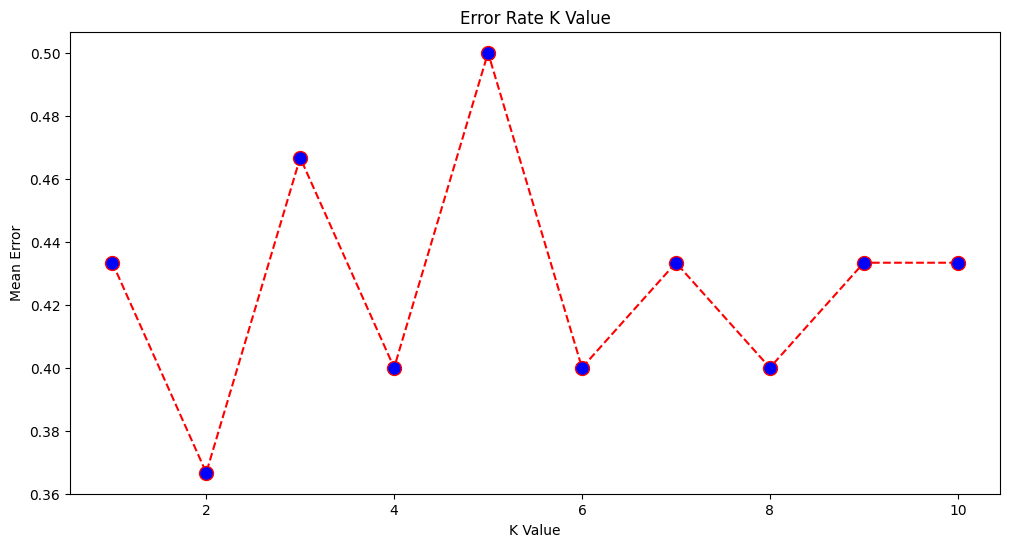

In [772]:
plt.figure(figsize=(12, 6))
plt.plot(range(1, 11), error, color = "red", linestyle = "dashed", marker = "o", markerfacecolor = "blue", markersize = 10)
plt.title("Error Rate K Value")
plt.xlabel("K Value")
plt.ylabel("Mean Error")

In [773]:
# !pip install --upgrade scikit-learn

In [817]:
# Escolha da quantidades de k que o modelo vai se aproximar.
from sklearn.neighbors import KNeighborsClassifier
modelo_classificador = KNeighborsClassifier(n_neighbors=4)
modelo_classificador.fit(x_knn_treino_scaled, y_knn_treino)

KNeighborsClassifier(n_neighbors=4)

In [818]:
# Um preditor é uma variável, sistema ou pessoa que antecipa, estima ou prevê um resultado futuro com base em dados, características (como idade/sexo) ou sinais (vibração/tensão).
# Utilizados em estatística, aprendizado de máquina e engenharias, ajudam a identificar tendências, riscos ou falhas precoces, otimizando decisões.
y_knn_predito = modelo_classificador.predict(x_knn_teste_scaled)

In [819]:
y_knn_predito

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0])

In [820]:
from sklearn.metrics import accuracy_score

In [821]:
# Metricas de precisão, revogação, f1-score e acurária
print(accuracy_score(y_knn_teste, y_knn_predito)) # relatório de valiação das métricas de desempenho.
print("\nRelatório:\n", classification_report(y_knn_teste, y_knn_predito))

0.6

Relatório:
               precision    recall  f1-score   support

           0       0.62      0.95      0.75        19
           1       0.00      0.00      0.00        11

    accuracy                           0.60        30
   macro avg       0.31      0.47      0.38        30
weighted avg       0.39      0.60      0.47        30



## 4.3 Modelo SVM - Entre 50% e 63%

In [780]:
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC

In [781]:
# separando x e y para o modelo knn - Features_1 - Accurancy de
x_svm_treino = treino[features_1] # variáveis independentes para treino
y_svm_treino = treino['target']   # target para treino

x_svm_teste = teste[features_1]   # variáveis independentes para teste
y_svm_teste = teste['target']     # target para teste

In [785]:
x_svm_treino_scaled = scaler.fit_transform(x_svm_treino) # só no treino
x_svm_teste_scaled = scaler.transform(x_svm_teste) #no teste (evita vazamento de dados)

In [786]:
y_svm_predito = modelo_classificador.predict(x_svm_teste_scaled)

In [799]:
svm = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    random_state=42)

svm.fit(x_svm_treino_scaled, y_svm_treino)

SVC(random_state=42)

In [795]:
svm = SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42)

svm.fit(x_svm_treino_scaled, y_svm_treino)

SVC(random_state=42)

In [796]:
y_predito_svm = svm.predict(x_svm_teste_scaled)

In [798]:
print(accuracy_score(y_svm_teste, y_predito_svm))
print("\nRelatório:\n", classification_report(y_svm_teste, y_svm_predito))

0.6

Relatório:
               precision    recall  f1-score   support

           0       0.59      0.68      0.63        19
           1       0.25      0.18      0.21        11

    accuracy                           0.50        30
   macro avg       0.42      0.43      0.42        30
weighted avg       0.47      0.50      0.48        30



In [801]:
# Ajustando hiperparâmetros
for C in [0.1, 1, 10, 100]:
    for gamma in [0.01, 0.1, 1]:
        svm = SVC(kernel="rbf", C=C, gamma=gamma)
        svm.fit(x_svm_treino_scaled, y_svm_treino)
        y_predito_svm = svm.predict(x_svm_teste_scaled)
        acc = accuracy_score(y_svm_teste, y_predito_svm)
        print(f"C={C}, gamma={gamma} → Accuracy={acc:.4f}")

C=0.1, gamma=0.01 → Accuracy=0.6333
C=0.1, gamma=0.1 → Accuracy=0.6333
C=0.1, gamma=1 → Accuracy=0.6333
C=1, gamma=0.01 → Accuracy=0.6333
C=1, gamma=0.1 → Accuracy=0.6333
C=1, gamma=1 → Accuracy=0.5667
C=10, gamma=0.01 → Accuracy=0.6333
C=10, gamma=0.1 → Accuracy=0.6000
C=10, gamma=1 → Accuracy=0.5667
C=100, gamma=0.01 → Accuracy=0.6333
C=100, gamma=0.1 → Accuracy=0.5667
C=100, gamma=1 → Accuracy=0.5667


In [ ]:
# Separando os dados
x_forest = df_ibov.drop(columns=['target', 'data', 'volume', 'var_targ'])
y_forest = df_ibov['target']
#Separando em bases de treino e teste
x_forest_train, x_forest_test, y__forest_train, y__forest_test = train_test_split(x_forest, y_forest, test_size=0.2, stratify=y_forest, random_state=7)

## 4.4 Decision tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier

In [823]:
x_dt_treino = treino[features_1]
y_dt_treino = treino["target"]

x_dt_teste = teste[features_1]
y_dt_teste = teste["target"]

In [824]:
# treinando o modelo
dt = DecisionTreeClassifier(
    max_depth=5,          # controla complexidade
    min_samples_split=20, # evita divisões muito pequenas
    random_state=42
)

dt.fit(x_dt_treino, y_dt_treino)

DecisionTreeClassifier(max_depth=5, min_samples_split=20, random_state=42)

In [ ]:

# modelo utilizando todas as variáveis do modelo
# d_tree = DecisionTreeClassifier(random_state=42, criterion = 'entropy', max_depth = 2)
# d_tree.fit(x_forest_train, y__forest_train)

In [825]:
y_predito_dt = dt.predict(x_dt_teste)

In [827]:
# Metricas de precisão, revocação, f1-score e acurácia.
print(accuracy_score(y_dt_teste, y_predito_dt)) #relatório de validação das métrica de desempenho.
print("\nRelatório:\n", classification_report(y_dt_teste, y_predito_dt))

0.5666666666666667

Relatório:
               precision    recall  f1-score   support

           0       0.61      0.89      0.72        19
           1       0.00      0.00      0.00        11

    accuracy                           0.57        30
   macro avg       0.30      0.45      0.36        30
weighted avg       0.38      0.57      0.46        30



In [830]:
# Teste de profundidade
# A profundidade da árvore impacta diretamente a performance
for depth in range(1, 11):
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt.fit(x_dt_treino, y_dt_treino)
    y_predito_dt = dt.predict(x_dt_teste)
    acc = accuracy_score(y_dt_teste, y_predito_dt)
    print(f"Profundidade={depth} → Accuracy={acc:.4f}")

Profundidade=1 → Accuracy=0.3667
Profundidade=2 → Accuracy=0.6333
Profundidade=3 → Accuracy=0.6333
Profundidade=4 → Accuracy=0.6333
Profundidade=5 → Accuracy=0.5667
Profundidade=6 → Accuracy=0.6333
Profundidade=7 → Accuracy=0.4667
Profundidade=8 → Accuracy=0.6000
Profundidade=9 → Accuracy=0.5667
Profundidade=10 → Accuracy=0.6333


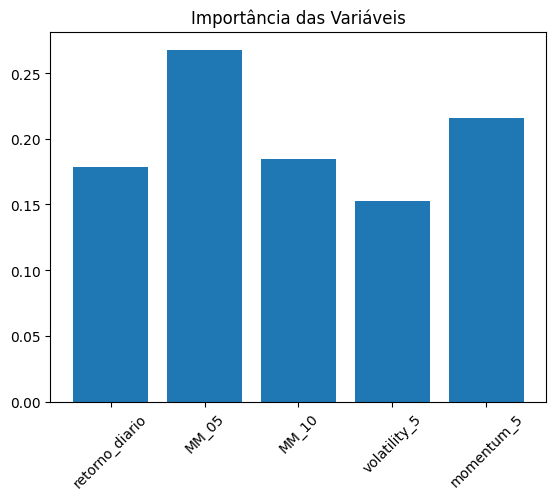

In [831]:
importances = dt.feature_importances_

plt.bar(features_1, importances)
plt.xticks(rotation=45)
plt.title("Importância das Variáveis")
plt.show()